<a href="https://colab.research.google.com/github/saadoonhammad/ieeecoins_data_imputation/blob/main/IEEE_COINS_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pandas as pd
import os

In [ ]:
#Load the Times New Roman Font
font_path ='/path/to/your/font/tnr.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()

In [ ]:
input_folder_path = '/path/to/your/input_data'
output_folder_path = '/path/to/your/data/results'
output_folder_csv = '/path/to/your/data/csvs'

# 150

In [ ]:
input_folder = '/path/to/your/input_data'
output_folder = '/path/to/your/data/plots'

dataframes= []
for filename in os.listdir(input_folder):
    if filename.endswith('.csv') and 'linear' not in filename:
        input_path = os.path.join(input_folder, filename)
        print(filename)
        df = pd.read_csv(input_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp')
        # Rename columns
        df.columns=[f"{col}_{filename.replace(filename, filename[23:29])}" if col != 'timestamp' else col for col in df.columns]
        dataframes.append(df)

# Merge DataFrames on timestamp
merged_df = pd.concat(dataframes, axis=1, join='inner')
merged_df = merged_df.reset_index()
# merged_df=merged_df.iloc[:,[0,1,3,5,7,9]]  #select relevant columns
merged_df=merged_df.iloc[:,[0,1,2,4,7,10]]  #select relevant columns
merged_df = merged_df.rename(columns={merged_df.columns[1]: 'original_val'})

output_path = os.path.join(output_folder, f"{filename[0:15]}_chart_{filename[20:23]}.csv")
merged_df.to_csv(output_path, index=False)
# print(f"Merged file saved to: {output_path}")


c01m045e01_2021_gap150_xgb.csv
c01m045e01_2021_gap150_spline.csv
c01m045e01_2021_gap_150_bilstm.csv
c01m045e01_2021_gap_150_mlp.csv


In [ ]:
merged_df

,timestamp,original_val,imputed_value_xgb.cs,imputed_value_spline,imputed__bilst,imputed__mlp.c
0,2021-09-04 11:20:00,22.3,20.404087,17.898551,22.584310,23.368119
1,2021-09-04 11:30:00,22.7,20.442078,17.979137,23.476192,23.493153
2,2021-09-04 11:40:00,22.8,20.492506,18.059952,23.222286,23.575352
3,2021-09-04 11:50:00,22.8,20.492506,18.140984,23.676131,23.852944
4,2021-09-04 12:00:00,22.9,21.940205,18.222222,23.718789,24.462768
...,...,...,...,...,...,...
145,2021-09-05 11:30:00,24.8,18.089933,26.405730,23.921439,26.614400
146,2021-09-05 11:40:00,24.8,18.140362,26.402724,23.948964,26.446240
147,2021-09-05 11:50:00,25.2,18.128326,26.398325,24.573675,26.600335
148,2021-09-05 12:00:00,25.3,19.588060,26.392522,24.439292,26.551455


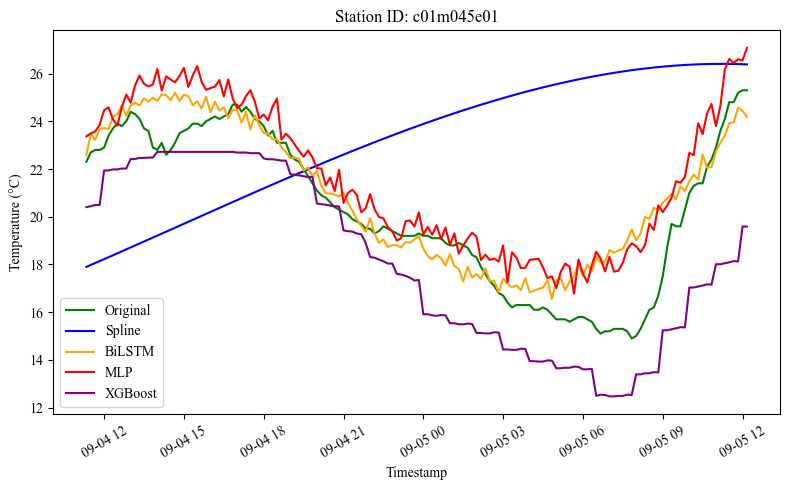

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(merged_df['timestamp'], merged_df['original_val'], label='Original', color='green')
plt.plot(merged_df['timestamp'], merged_df['imputed_value_spline'], label='Spline', color='blue')
plt.plot(merged_df['timestamp'], merged_df['imputed__bilst'], label='BiLSTM', color='orange')
plt.plot(merged_df['timestamp'], merged_df['imputed__mlp.c'], label='MLP', color='red')
plt.plot(merged_df['timestamp'], merged_df['imputed_value_xgb.cs'], label='XGBoost', color='purple')

# plt.title("Merged Linear and BiLSTM Imputations (Gap Size: 300)")
plt.title(f"Station ID: {filename[0:10]}")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
output_path = os.path.join(output_folder, f"{filename[0:10]}_imputation_plot_{filename[20:23]}.png")
plt.savefig(output_path, dpi=300)
plt.show()
# print(f"Merged file saved to: {output_path}")

# 300

In [ ]:
input_folder = '/path/to/your/input_data'
output_folder = '/path/to/your/data/plots'

dataframes= []
for filename in os.listdir(input_folder):
    if filename.endswith('.csv') and 'linear' not in filename:
        input_path = os.path.join(input_folder, filename)
        print(filename)
        df = pd.read_csv(input_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp')
        # Rename columns
        df.columns=[f"{col}_{filename.replace(filename, filename[23:29])}" if col != 'timestamp' else col for col in df.columns]
        dataframes.append(df)

# Merging DataFrames on timestamp
merged_df = pd.concat(dataframes, axis=1, join='inner')
merged_df = merged_df.reset_index()
merged_df=merged_df.iloc[:,[0,1,3,5,7,10]]  #select relevant columns
merged_df = merged_df.rename(columns={merged_df.columns[1]: 'original_val'})

output_path = os.path.join(output_folder, f"{filename[0:15]}_chart_{filename[20:23]}.csv")
merged_df.to_csv(output_path, index=False)
# print(f"Merged file saved to: {output_path}")


c01m045e01_2021_gap_300_mlp.csv
c01m045e01_2021_gap300_xgb.csv
c01m045e01_2021_gap300_spline.csv
c01m045e01_2021_gap_300_bilstm.csv


In [ ]:
merged_df

,timestamp,original_val,imputed__mlp.c,imputed_value_xgb.cs,imputed_value_spline,imputed__bilst
0,2021-09-04 11:20:00,22.3,23.368119,20.404087,17.493998,22.584310
1,2021-09-04 11:30:00,22.7,23.493153,20.442078,17.562546,23.476192
2,2021-09-04 11:40:00,22.8,23.575352,20.492506,17.631697,23.222286
3,2021-09-04 11:50:00,22.8,23.852944,20.492506,17.701443,23.676131
4,2021-09-04 12:00:00,22.9,24.462768,21.940205,17.771775,23.718789
...,...,...,...,...,...,...
295,2021-09-06 12:30:00,27.8,28.076337,18.808815,30.410352,25.528683
296,2021-09-06 12:40:00,27.9,27.457703,18.844961,30.314287,26.170926
297,2021-09-06 12:50:00,28.3,28.502885,18.844961,30.216495,25.624209
298,2021-09-06 13:00:00,28.8,28.341055,19.179867,30.116969,26.251956


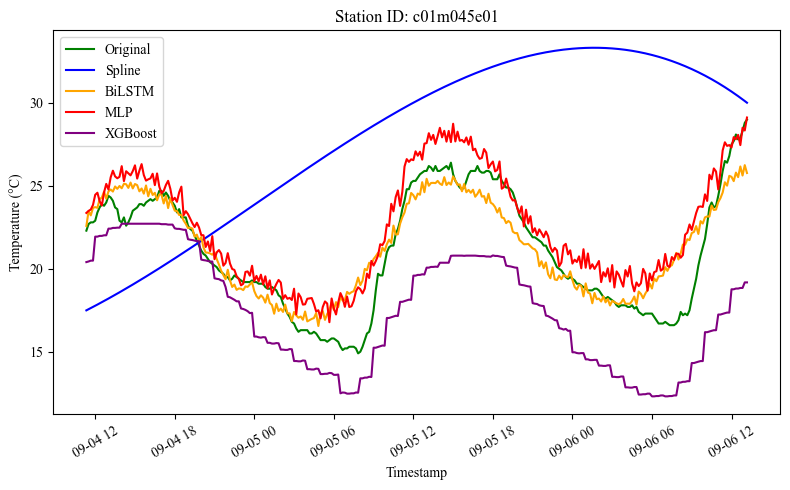

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(merged_df['timestamp'], merged_df['original_val'], label='Original', color='green')
plt.plot(merged_df['timestamp'], merged_df['imputed_value_spline'], label='Spline', color='blue')
plt.plot(merged_df['timestamp'], merged_df['imputed__bilst'], label='BiLSTM', color='orange')
plt.plot(merged_df['timestamp'], merged_df['imputed__mlp.c'], label='MLP', color='red')
plt.plot(merged_df['timestamp'], merged_df['imputed_value_xgb.cs'], label='XGBoost', color='purple')

# plt.title("Merged Linear and BiLSTM Imputations (Gap Size: 300)")
plt.title(f"Station ID: {filename[0:10]}")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
output_path = os.path.join(output_folder, f"{filename[0:10]}_imputation_plot_{filename[20:23]}.png")
plt.savefig(output_path, dpi=300)
plt.show()
# print(f"Merged file saved to: {output_path}")

# 450

In [ ]:
input_folder = '/path/to/your/input_data'
output_folder = '/path/to/your/data/plots'
dataframes= []

for filename in os.listdir(input_folder):
    if filename.endswith('.csv') and 'linear' not in filename:
        input_path = os.path.join(input_folder, filename)
        print(filename)
        df = pd.read_csv(input_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp')
        # Rename columns
        df.columns=[f"{col}_{filename.replace(filename, filename[23:29])}" if col != 'timestamp' else col for col in df.columns]
        # df.columns = [f"{col}_{filename.replace(filename, filename[24:30])}" if col != 'timestamp' else col for col in df.columns]
        dataframes.append(df)

# Merge all DataFrames on timestamp using outer join
merged_df = pd.concat(dataframes, axis=1, join='inner')
merged_df = merged_df.reset_index()
merged_df=merged_df.iloc[:,[0,1,3,6,8,10]]  #select relevant columns
merged_df = merged_df.rename(columns={merged_df.columns[1]: 'original_val'})


output_path = os.path.join(output_folder, f"{filename[0:15]}_chart_{filename[20:23]}.csv")
merged_df.to_csv(output_path, index=False)
# print(f"Merged file saved to: {output_path}")

In [ ]:
merged_df

,timestamp,original_val,imputed__mlp.c,imputed__bilst,imputed_value_xgb.cs,imputed_value__splin
0,2021-09-04 11:20:00,22.3,23.368119,22.584310,20.404087,19.847591
1,2021-09-04 11:30:00,22.7,23.493153,23.476192,20.442078,20.034704
2,2021-09-04 11:40:00,22.8,23.575352,23.222286,20.492506,20.220760
3,2021-09-04 11:50:00,22.8,23.852944,23.676131,20.492506,20.405761
4,2021-09-04 12:00:00,22.9,24.462768,23.718789,21.940205,20.589711
...,...,...,...,...,...,...
445,2021-09-07 13:30:00,24.6,28.876846,26.228291,24.436010,26.562391
446,2021-09-07 13:40:00,24.7,28.428374,25.947118,24.451420,26.467683
447,2021-09-07 13:50:00,24.8,29.064505,26.040727,24.451420,26.372766
448,2021-09-07 14:00:00,24.7,29.499220,25.882546,24.708645,26.277643


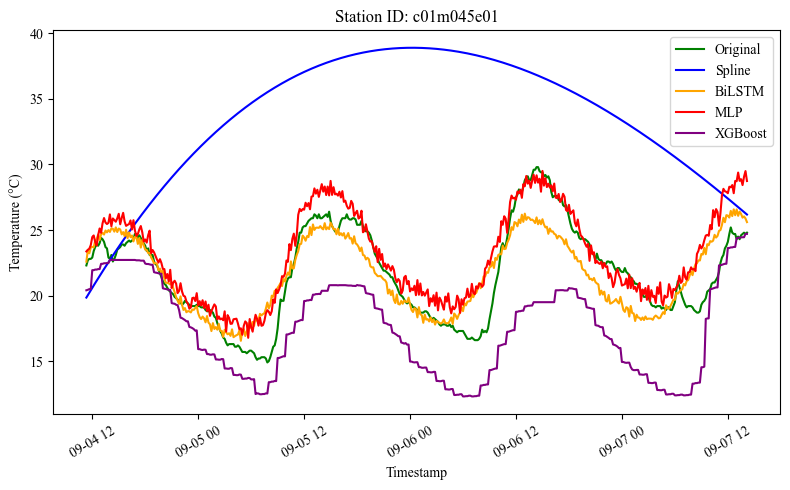

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(merged_df['timestamp'], merged_df['original_val'], label='Original', color='green')
plt.plot(merged_df['timestamp'], merged_df['imputed_value__splin'], label='Spline', color='blue')
plt.plot(merged_df['timestamp'], merged_df['imputed__bilst'], label='BiLSTM', color='orange')
plt.plot(merged_df['timestamp'], merged_df['imputed__mlp.c'], label='MLP', color='red')
plt.plot(merged_df['timestamp'], merged_df['imputed_value_xgb.cs'], label='XGBoost', color='purple')

# plt.title("Merged Linear and BiLSTM Imputations (Gap Size: 300)")
plt.title(f"Station ID: {filename[0:10]}")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
output_path = os.path.join(output_folder, f"{filename[0:10]}_imputation_plot_{filename[20:23]}.png")
plt.savefig(output_path, dpi=300)
plt.show()
# print(f"Merged file saved to: {output_path}")

# 600

In [ ]:
input_folder = '/path/to/your/input_data'
output_folder = '/path/to/your/data/plots'

dataframes= []
for filename in os.listdir(input_folder):
    if filename.endswith('.csv') and 'linear' not in filename:
        input_path = os.path.join(input_folder, filename)
        print(filename)
        df = pd.read_csv(input_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp')
        # Rename columns
        df.columns=[f"{col}_{filename.replace(filename, filename[23:29])}" if col != 'timestamp' else col for col in df.columns]
        # df.columns = [f"{col}_{filename.replace(filename, filename[24:30])}" if col != 'timestamp' else col for col in df.columns]
        dataframes.append(df)

# Merge all DataFrames on timestamp using outer join
merged_df = pd.concat(dataframes, axis=1, join='inner')
merged_df = merged_df.reset_index()
merged_df=merged_df.iloc[:,[0,1,3,5,7,10]]  #select relevant columns
merged_df = merged_df.rename(columns={merged_df.columns[1]: 'original_val'})

output_path = os.path.join(output_folder, f"{filename[0:15]}_chart_{filename[20:23]}.csv")
merged_df.to_csv(output_path, index=False)
# print(f"Merged file saved to: {output_path}")

c01m045e01_2021_gap_600_mlp.csv
c01m045e01_2021_gap600_xgb.csv
c01m045e01_2021_gap600_spline.csv
c01m045e01_2021_gap_600_bilstm.csv


In [ ]:
merged_df

,timestamp,original_val,imputed__mlp.c,imputed_value_xgb.cs,imputed_value_spline,imputed__bilst
0,2021-09-04 11:20:00,22.3,23.368119,20.404087,18.478904,22.584310
1,2021-09-04 11:30:00,22.7,23.493153,20.442078,18.575817,23.476192
2,2021-09-04 11:40:00,22.8,23.575352,20.492506,18.672700,23.222286
3,2021-09-04 11:50:00,22.8,23.852944,20.492506,18.769554,23.676131
4,2021-09-04 12:00:00,22.9,24.462768,21.940205,18.866376,23.718789
...,...,...,...,...,...,...
595,2021-09-08 14:30:00,25.6,28.910461,24.953217,26.375432,25.820811
596,2021-09-08 14:40:00,26.1,28.966789,24.953217,26.229181,26.069748
597,2021-09-08 14:50:00,25.9,27.679826,24.953217,26.082139,25.788480
598,2021-09-08 15:00:00,25.9,29.360480,24.953217,25.934306,26.052783


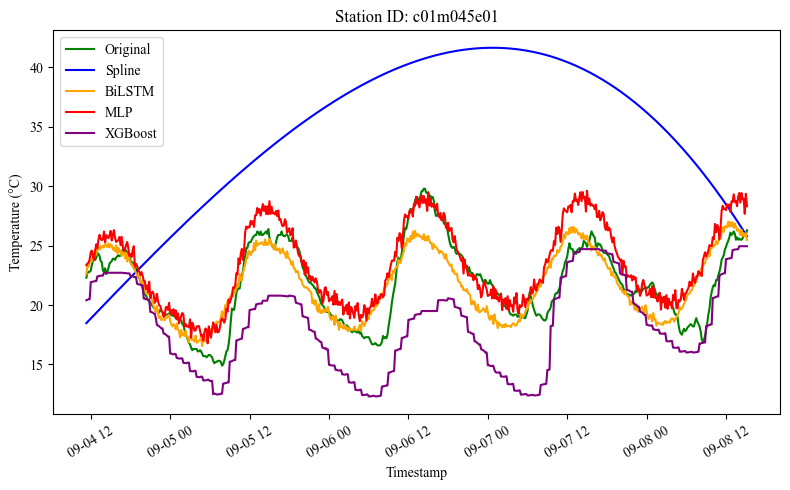

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(merged_df['timestamp'], merged_df['original_val'], label='Original', color='green')
plt.plot(merged_df['timestamp'], merged_df['imputed_value_spline'], label='Spline', color='blue')
plt.plot(merged_df['timestamp'], merged_df['imputed__bilst'], label='BiLSTM', color='orange')
plt.plot(merged_df['timestamp'], merged_df['imputed__mlp.c'], label='MLP', color='red')
plt.plot(merged_df['timestamp'], merged_df['imputed_value_xgb.cs'], label='XGBoost', color='purple')

# plt.title("Merged Linear and BiLSTM Imputations (Gap Size: 300)")
plt.title(f"Station ID: {filename[0:10]}")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
output_path = os.path.join(output_folder, f"{filename[0:10]}_imputation_plot_{filename[20:23]}.png")
plt.savefig(output_path, dpi=300)
plt.show()
# print(f"Merged file saved to: {output_path}")